In [1]:
import cajal.sample_swc
import cajal.swc


In [2]:
#dist matrix with only metadata SWCs
cajal.sample_swc.compute_icdm_all_euclidean(
    infolder = "/home/njay/cajal/Data/NewGouwen_pathseq_data/NewGouwen_downsample_swc",
    out_csv="../data/processed/downsample_noaxons_gouwen_patch_seq_100pts_euclidean_icdm.csv",
    preprocess=cajal.swc.preprocessor_eu(
        structure_ids=[1,3,4],
        soma_component_only=False),
    n_sample=100,
    num_processes=8)  # num_processes can be set to the number of cores on your machine


 99%|████████████████████████████████████████████████████████████████████████████████▍| 148/149 [00:51<00:00,  2.88it/s]


[]

In [3]:
import cajal.run_gw

cajal.run_gw.compute_gw_distance_matrix(
    "../data/processed/downsample_noaxons_gouwen_patch_seq_100pts_euclidean_icdm.csv",
    "../data/processed/downsample_gouwen_patchseq_100pts_euclidean_GW_dmat.csv",
    num_processes=8)


  0%|          | 0/11026 [00:00<?, ?it/s]

(array([[ 0.        , 38.22743013, 16.45976823, ..., 26.73660459,
         40.29297127, 51.14970062],
        [38.22743013,  0.        , 46.72254593, ..., 38.10322589,
         27.45985144, 30.22175886],
        [16.45976823, 46.72254593,  0.        , ..., 31.26838299,
         48.38899398, 60.61569619],
        ...,
        [26.73660459, 38.10322589, 31.26838299, ...,  0.        ,
         30.003621  , 41.00725055],
        [40.29297127, 27.45985144, 48.38899398, ..., 30.003621  ,
          0.        , 33.86199711],
        [51.14970062, 30.22175886, 60.61569619, ..., 41.00725055,
         33.86199711,  0.        ]]),
 None)

In [3]:
import plotly.io as pio
pio.renderers.default = 'iframe'

import cajal.utilities
import umap
import plotly.express

# Read GW distance matrix
cells, gw_dist_dict = cajal.utilities.read_gw_dists("../data/processed/downsample_gouwen_patchseq_100pts_euclidean_GW_dmat.csv", header=True)
gw_dist = cajal.utilities.dist_mat_of_dict(gw_dist_dict)

# Compute UMAP representation
reducer = umap.UMAP(metric="precomputed", random_state=1)
embedding = reducer.fit_transform(gw_dist)

# Visualize UMAP
plotly.express.scatter(x=embedding[:,0],
                       y=embedding[:,1],
                       template="simple_white",
                       hover_name=[m + ".swc" for m in cells])

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/downsample_gouwen_patchseq_100pts_euclidean_GW_dmat.csv'

In [6]:
clusters = cajal.utilities.leiden_clustering(gw_dist, seed=1)
plotly.express.scatter(x=embedding[:,0],
                       y=embedding[:,1],
                       template="simple_white",
                       hover_name=[m + ".swc" for m in cells],
                       color = [str(m) for m in clusters])

In [5]:
import pandas
cells_without_suffix = [specimen_id.replace('_transformed', '') for specimen_id in cells]

metadata = pandas.read_csv("../data/raw/NewGouwen_metadata.csv")
metadata.index = [str(m) for m in metadata["Specimen ID"]]
metadata = metadata.loc[cells_without_suffix]

# Assuming that 'embedding' is a NumPy array
filtered_embedding = embedding
#[:474, :]
filtered_hover_name = [m + ".swc" for m in cells_without_suffix]
#[:474]
plotly.express.scatter(
        x=filtered_embedding[:, 0],
        y=filtered_embedding[:, 1],
        template="simple_white",
        hover_name=filtered_hover_name,
        color=metadata["T type sub-class"]
)

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/NewGouwen_metadata.csv'

In [8]:
import pandas
plotly.express.scatter(x=embedding[:,0],
                       y=embedding[:,1],
                       template="simple_white",
                       hover_name=[m + ".swc" for m in cells_without_suffix],
                       color = metadata["T type"], title = "T type"
                      )

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cell_type = numpy.array(metadata["T type sub-class"])

clf = RandomForestClassifier(n_estimators=100, random_state=1)
cv = StratifiedKFold(n_splits=5, shuffle=True)
accuracy = cross_val_score(clf, X=gw_dist, y=cell_type, cv=cv)

numpy.mean(accuracy)


/home/njay/miniconda3/envs/morphoL/lib/python3.9/site-packages/sklearn/model_selection/_split.py:737: UserWarning:

The least populated class in y has only 1 members, which is less than n_splits=5.



0.5577011494252874

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cell_type = numpy.array(metadata["T type"])

clf = RandomForestClassifier(n_estimators=100, random_state=1)
cv = StratifiedKFold(n_splits=5, shuffle=True)
accuracy = cross_val_score(clf, X=gw_dist, y=cell_type, cv=cv)

numpy.mean(accuracy)


/home/njay/miniconda3/envs/morphoL/lib/python3.9/site-packages/sklearn/model_selection/_split.py:737: UserWarning:

The least populated class in y has only 1 members, which is less than n_splits=5.



0.12091954022988505

0.26416666666666666


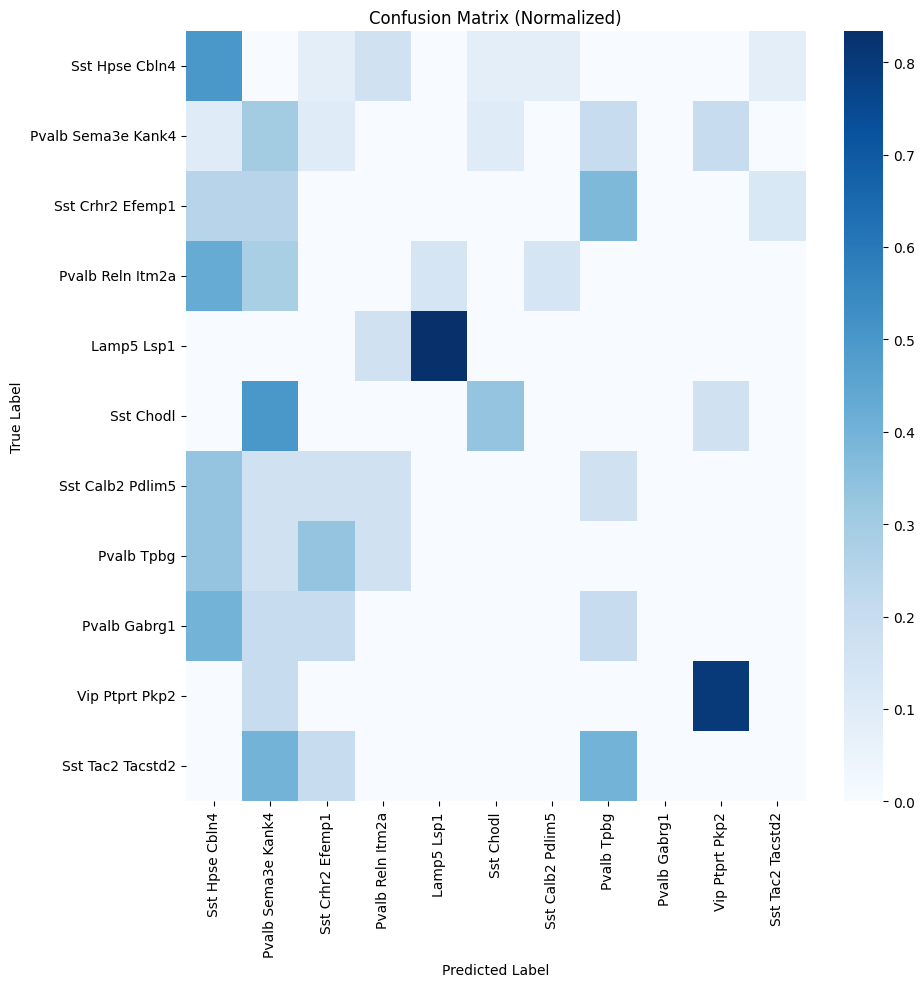

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cell_type = np.array(metadata["T type"])

# Count the occurrences of each class
class_counts = pd.Series(cell_type).value_counts()

# Filter classes with at least 5 occurrences
selected_classes = class_counts[class_counts >= 5].index
class_indices = metadata["T type"].isin(selected_classes)
filtered_metadata = metadata[class_indices]
filtered_gw_dist = gw_dist[class_indices, :]

# Create a RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=0)
# Use StratifiedKFold for cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True)
accuracy = cross_val_score(clf, X=filtered_gw_dist, y=cell_type[class_indices], cv=cv)
mean_accuracy = np.mean(accuracy)
print(mean_accuracy)  # Print the mean accuracy

# Make predictions using cross-validation
predictions = cross_val_predict(clf, X=filtered_gw_dist, y=cell_type[class_indices], cv=cv)

# Create a confusion matrix
conf_mat = confusion_matrix(cell_type[class_indices], predictions, labels=selected_classes)

# Normalize the confusion matrix to get percentages
conf_mat_percentage = conf_mat / conf_mat.sum(axis=1)[:, np.newaxis]

# Create a DataFrame for better visualization
conf_mat_df = pd.DataFrame(conf_mat_percentage, index=selected_classes, columns=selected_classes)

# Plot the heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(conf_mat_df, annot=False, cmap="Blues", fmt=".2f")
plt.title("Confusion Matrix (Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


0.6085057471264367


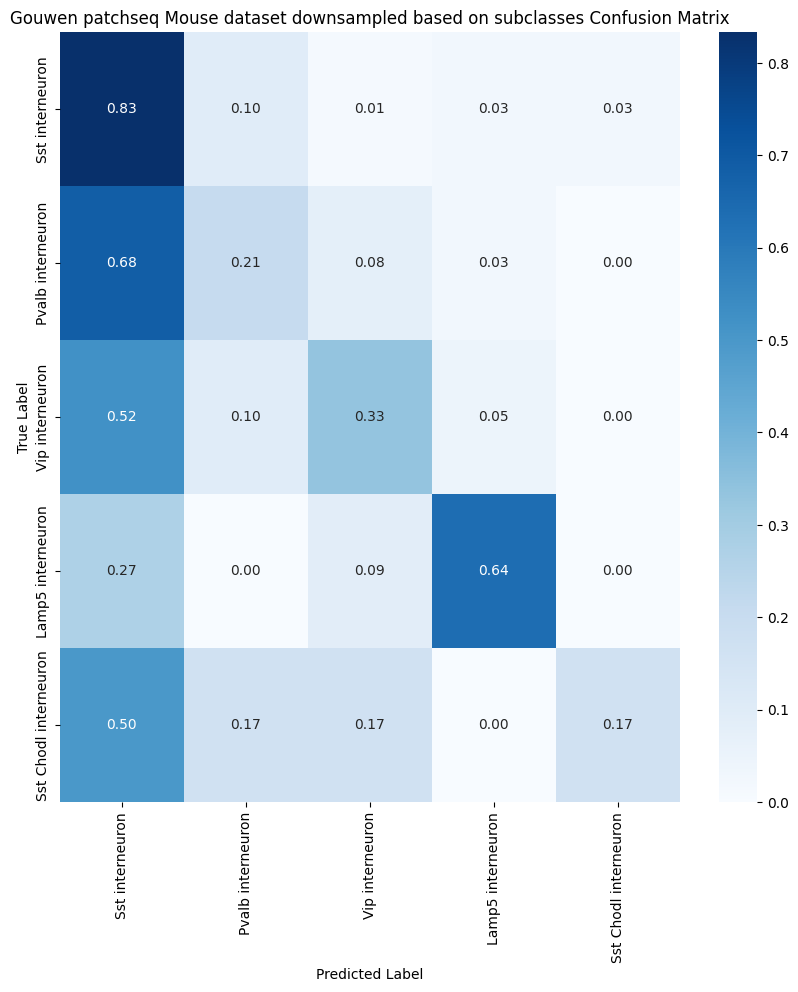

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
cell_type = np.array(metadata["T type sub-class"])

# Count the occurrences of each class
class_counts = pd.Series(cell_type).value_counts()

# Filter classes with at least 5 occurrences
selected_classes = class_counts[class_counts >= 5].index

# Filter the metadata and feature matrix based on selected classes
class_indices = metadata["T type sub-class"].isin(selected_classes)
filtered_metadata = metadata[class_indices]
filtered_gw_dist = gw_dist[class_indices, :]

# Create a RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=0)

# Use StratifiedKFold for cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True)
accuracy = cross_val_score(clf, X=filtered_gw_dist, y=cell_type[class_indices], cv=cv)

mean_accuracy = np.mean(accuracy)
print(mean_accuracy)  # Print the mean accuracy
# Make predictions using cross-validation
predictions = cross_val_predict(clf, X=filtered_gw_dist, y=cre_lines[class_indices], cv=cv)

# Create a confusion matrix
conf_mat = confusion_matrix(cell_type[class_indices], predictions, labels=selected_classes)

# Normalize the confusion matrix to get percentages
conf_mat_percentage = conf_mat / conf_mat.sum(axis=1)[:, np.newaxis]

# Create a DataFrame for better visualization
conf_mat_df = pd.DataFrame(conf_mat_percentage, index=selected_classes, columns=selected_classes)

# Plot the heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(conf_mat_df, annot=True, cmap="Blues", fmt=".2f")
plt.title("Gouwen patchseq Mouse dataset downsampled based on subclasses Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


Mean Accuracy (Random Forest): 0.6085057471264367
Mean Accuracy (Dummy Classifier - Stratified): 0.31103448275862067
Mean Accuracy (Dummy Classifier - Uniform): 0.17609195402298852


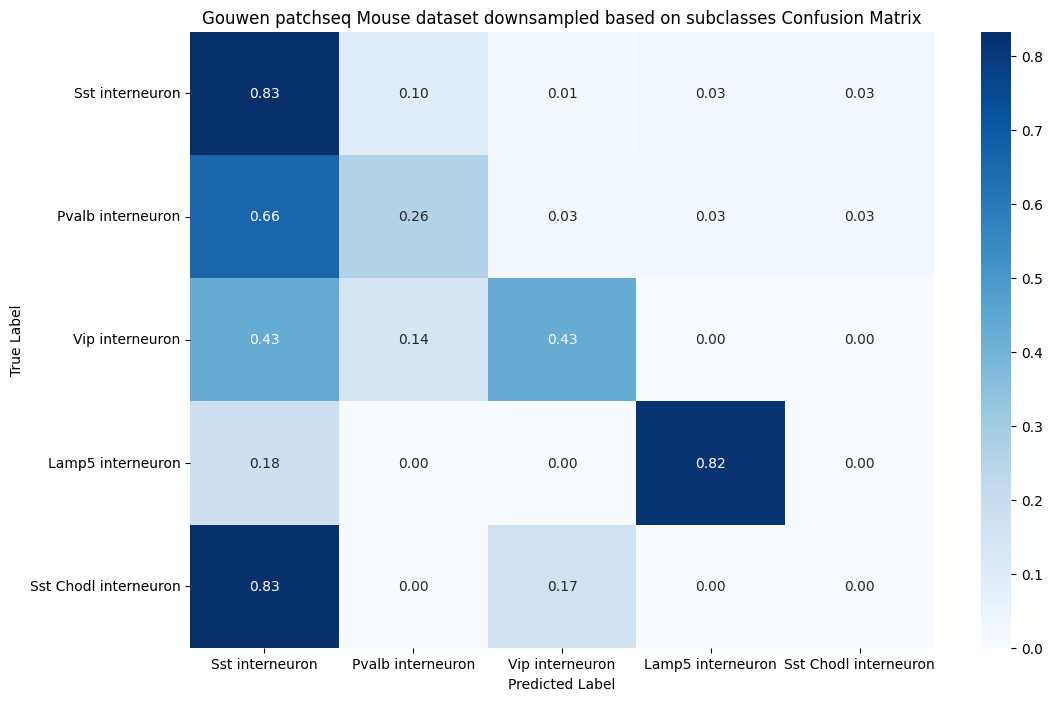

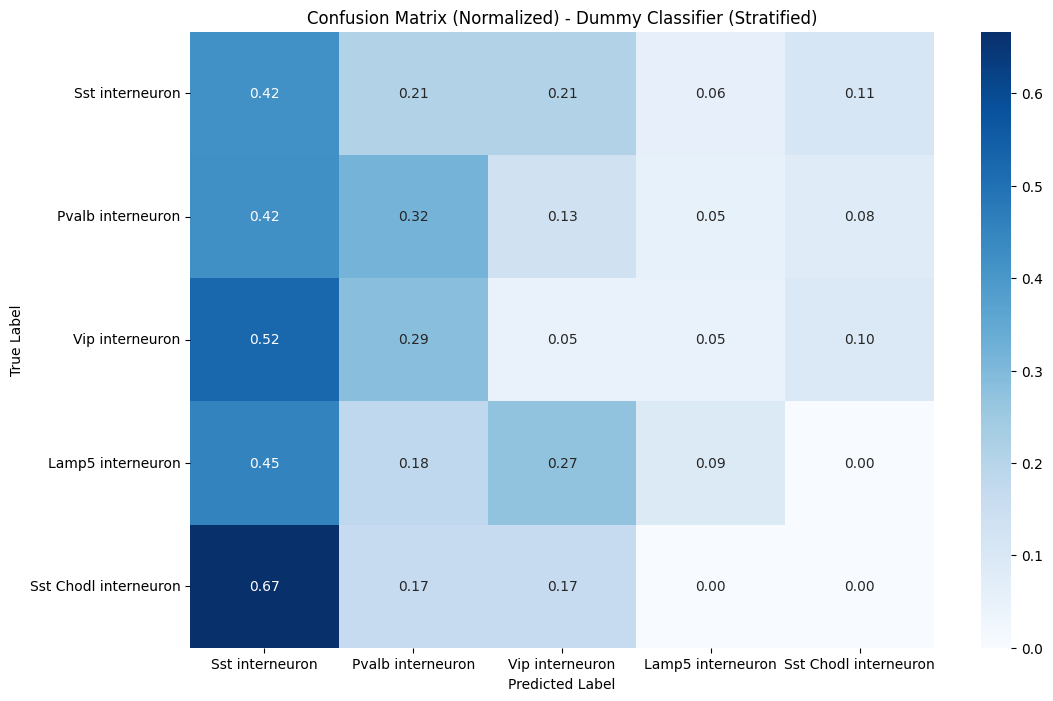

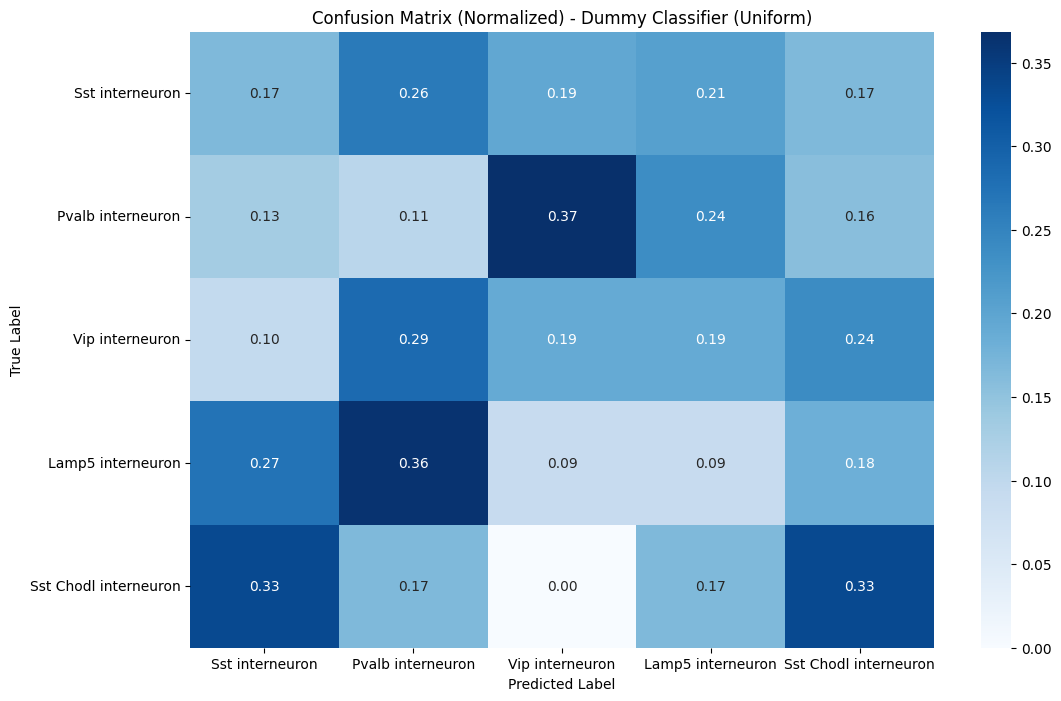

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier

cell_type = np.array(metadata["T type sub-class"])

# Count the occurrences of each class
class_counts = pd.Series(cell_type).value_counts()

# Filter classes with at least 5 occurrences
selected_classes = class_counts[class_counts >= 5].index
class_indices = metadata["T type sub-class"].isin(selected_classes)
filtered_metadata = metadata[class_indices]
filtered_gw_dist = gw_dist[class_indices, :]

# Create a RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=0)

# Use StratifiedKFold for cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True)

# Evaluate RandomForestClassifier
accuracy_rf = cross_val_score(clf, X=filtered_gw_dist, y=cell_type[class_indices], cv=cv)
mean_accuracy_rf = np.mean(accuracy_rf)

# Generate random baselines
dummy_strat = DummyClassifier(strategy="stratified")
dummy_uniform = DummyClassifier(strategy="uniform")

accuracy_dummy_strat = cross_val_score(dummy_strat, X=filtered_gw_dist, y=cell_type[class_indices], cv=cv)
accuracy_dummy_uniform = cross_val_score(dummy_uniform, X=filtered_gw_dist, y=cell_type[class_indices], cv=cv)

mean_accuracy_dummy_strat = np.mean(accuracy_dummy_strat)
mean_accuracy_dummy_uniform = np.mean(accuracy_dummy_uniform)

# Print mean accuracies
print("Mean Accuracy (Random Forest):", mean_accuracy_rf)
print("Mean Accuracy (Dummy Classifier - Stratified):", mean_accuracy_dummy_strat)
print("Mean Accuracy (Dummy Classifier - Uniform):", mean_accuracy_dummy_uniform)

# Plotting Confusion Matrix for RandomForestClassifier
predictions_rf = cross_val_predict(clf, X=filtered_gw_dist, y=cell_type[class_indices], cv=cv)
conf_mat_rf = confusion_matrix(cell_type[class_indices], predictions_rf, labels=selected_classes)
conf_mat_percentage_rf = conf_mat_rf / conf_mat_rf.sum(axis=1)[:, np.newaxis]
conf_mat_df_rf = pd.DataFrame(conf_mat_percentage_rf, index=selected_classes, columns=selected_classes)

plt.figure(figsize=(12, 8))
sns.heatmap(conf_mat_df_rf, annot=True, cmap="Blues", fmt=".2f")
plt.title("Gouwen patchseq Mouse dataset downsampled based on subclasses Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# Plotting Confusion Matrix for Dummy Classifier - Stratified
predictions_dummy_strat = cross_val_predict(dummy_strat, X=filtered_gw_dist, y=cell_type[class_indices], cv=cv)
conf_mat_dummy_strat = confusion_matrix(cell_type[class_indices], predictions_dummy_strat, labels=selected_classes)
conf_mat_percentage_dummy_strat = conf_mat_dummy_strat / conf_mat_dummy_strat.sum(axis=1)[:, np.newaxis]
conf_mat_df_dummy_strat = pd.DataFrame(conf_mat_percentage_dummy_strat, index=selected_classes, columns=selected_classes)

plt.figure(figsize=(12, 8))
sns.heatmap(conf_mat_df_dummy_strat, annot=True, cmap="Blues", fmt=".2f")
plt.title("Confusion Matrix (Normalized) - Dummy Classifier (Stratified)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig('mouse dummy_confusion_matrix_stratified.png')
plt.show()

# Plotting Confusion Matrix for Dummy Classifier - Uniform
predictions_dummy_uniform = cross_val_predict(dummy_uniform, X=filtered_gw_dist, y=cell_type[class_indices], cv=cv)
conf_mat_dummy_uniform = confusion_matrix(cell_type[class_indices], predictions_dummy_uniform, labels=selected_classes)
conf_mat_percentage_dummy_uniform = conf_mat_dummy_uniform / conf_mat_dummy_uniform.sum(axis=1)[:, np.newaxis]
conf_mat_df_dummy_uniform = pd.DataFrame(conf_mat_percentage_dummy_uniform, index=selected_classes, columns=selected_classes)

plt.figure(figsize=(12, 8))
sns.heatmap(conf_mat_df_dummy_uniform, annot=True, cmap="Blues", fmt=".2f")
plt.title("Confusion Matrix (Normalized) - Dummy Classifier (Uniform)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig('mouse dummy_confusion_matrix_uniform.png')
plt.show()
